# Credit Risk Statistics, Modeling, and Inference


| | |
|---|---|
| **Notebook** | B2_Statistics_Modeling_and_Inference.ipynb |
| **Author** | N L N Sai Krishna Akula |
| **Course** | AAI 500 - Applied Statistics & AI |
| **Dataset** | Credit Risk Modeling Dataset |
| **Date** | June 3, 2026 |
| **GitHub** | https://github.com/diaeshantony-usd/applied-statistics-and-ai-team-project |


This notebook starts from the saved Phase 2 modeling dataset. It runs inferential statistics, Bayesian Network modeling, ML classification, ML regression, model saving, and final applicant inference.


In [47]:
# Core data libraries
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# Inferential statistics
from scipy import stats

# Scikit-learn preprocessing
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Scikit-learn model selection and metrics
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)

# Scikit-learn estimators
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from catboost import CatBoostClassifier
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20
PHASE2_DATA_PATH = "../data/processed/phase2/credit_risk_cleaned.csv"
CLASSIFICATION_MODEL_DIR = Path("../data/models/classification")
REGRESSION_MODEL_DIR = Path("../data/models/regression")
BAYESIAN_MODEL_DIR = Path("../data/models/bayesian_network")

print("Libraries loaded successfully.")
print("Phase 2 dataset configured:", PHASE2_DATA_PATH)
print("Classification model folder:", CLASSIFICATION_MODEL_DIR)
print("Regression model folder:", REGRESSION_MODEL_DIR)
print("Bayesian Network model folder:", BAYESIAN_MODEL_DIR)


Libraries loaded successfully.
Phase 2 dataset configured: ../data/processed/phase2/credit_risk_cleaned.csv
Classification model folder: ..\data\models\classification
Regression model folder: ..\data\models\regression
Bayesian Network model folder: ..\data\models\bayesian_network


---
## Setup for Statistics and Modeling

This notebook starts from the saved Phase 2 CSV created in Notebook 1. The setup cell includes the imports, paths, and helper functions needed to run the statistics, modeling, saved-model loading, and applicant inference steps.


In [48]:
def add_credit_features(data):
    # Copy the input so the original cleaned dataset is not modified directly.
    out = data.copy()

    # Log transforms reduce the influence of very large income and loan values.
    out["log_person_income"] = np.log1p(out["person_income"])
    out["log_loan_amnt"] = np.log1p(out["loan_amnt"])

    # Ratio features describe affordability and borrower history in relative terms.
    out["income_to_loan_ratio"] = out["person_income"] / out["loan_amnt"].clip(lower=1)
    out["employment_to_age_ratio"] = out["person_emp_length"] / out["person_age"].clip(lower=1)
    out["credit_history_to_age_ratio"] = out["cb_person_cred_hist_length"] / out["person_age"].clip(lower=1)
    out["default_on_file_binary"] = (out["cb_person_default_on_file"] == "Y").astype(int)

    # Numeric grade is useful for analysis while model preprocessing still handles grade encoding.
    grade_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}
    out["loan_grade_numeric"] = out["loan_grade"].map(grade_map)

    # Grouped features make borrower and loan risk patterns easier to explain.
    out["income_group"] = pd.cut(
        out["person_income"],
        bins=[0, 25000, 50000, 75000, 100000, np.inf],
        labels=["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"],
        include_lowest=True,
    )
    out["loan_amount_group"] = pd.cut(
        out["loan_amnt"],
        bins=[0, 5000, 10000, 20000, np.inf],
        labels=["Small", "Medium", "Large", "Very Large"],
        include_lowest=True,
    )
    out["loan_percent_income_group"] = pd.cut(
        out["loan_percent_income"],
        bins=[0, 0.10, 0.20, 0.35, np.inf],
        labels=["Low Burden", "Moderate Burden", "High Burden", "Very High Burden"],
        include_lowest=True,
    )
    out["age_group"] = pd.cut(
        out["person_age"],
        bins=[0, 25, 35, np.inf],
        labels=["Young", "Adult", "Experienced Adult"],
        include_lowest=True,
    )
    # Return the feature-engineered dataframe for all later modeling steps.
    return out

---
## 3. Statistical and Bayesian Analysis

### 3.1 Inferential Statistics

Chapter 3 starts by loading the saved Phase 2 dataset. This makes the statistics and modeling steps reproducible without depending on earlier notebook cells already being in memory. Inferential statistics help check whether group differences look real or could just be random. This dataset supports mean-comparison tests for borrower, loan, and credit-history variables.

Welch's t-test is used for two-group comparisons between default and non-default loans because it does not assume equal variance between the groups. One-way ANOVA is used to compare numeric means across more than two credit grades.

**H0** means the null hypothesis. It represents the assumption that there is no real difference between the groups being compared. If the p-value is below 0.05, the result rejects H0, meaning the observed difference is unlikely to be explained by random variation alone.


In [49]:
# Reload the saved modeling dataset before statistics and modeling.
df_model = pd.read_csv(PHASE2_DATA_PATH)
print("Modeling dataset loaded successfully.")
print("Shape:", df_model.shape)
df_model.head()

Modeling dataset loaded successfully.
Shape: (29567, 23)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_income,log_loan_amnt,income_to_loan_ratio,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,loan_grade_numeric,income_group,loan_amount_group,loan_percent_income_group,age_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.169623,6.908755,9.600000,0.238095,0.095238,0,1,Low,Small,Low Burden,Young
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,9.169623,8.612685,1.745455,0.040000,0.120000,0,2,Low,Medium,Very High Burden,Young
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,11.089821,10.463132,1.871429,0.173913,0.086957,0,2,Middle,Very Large,Very High Burden,Young
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,10.904138,10.463132,1.554286,0.333333,0.166667,1,2,Middle,Very Large,Very High Burden,Young
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,9.200391,7.824446,3.960000,0.095238,0.095238,0,0,Low,Small,High Burden,Young


In [50]:
ALPHA = 0.05

ttest_numeric_features = [
    "person_income", "loan_amnt", "loan_percent_income",
    "loan_int_rate", "person_emp_length", "cb_person_cred_hist_length",
]


def run_welch_tests(data, features, target_col="loan_status", alpha=ALPHA):
    # Welch's t-test compares numeric means between default and non-default loans.
    rows = []
    for feature in features:
        non_default_values = data.loc[data[target_col] == 0, feature].dropna()
        default_values = data.loc[data[target_col] == 1, feature].dropna()

        # equal_var=False applies Welch's version of the independent t-test.
        statistic, p_value = stats.ttest_ind(
            non_default_values,
            default_values,
            equal_var=False,
            nan_policy="omit",
        )
        decision = "Reject H0" if p_value < alpha else "Fail to reject H0"
        interpretation = (
            "Reject H0: evidence suggests the mean differs by default status."
            if p_value < alpha
            else "Fail to reject H0: no statistically significant mean difference found."
        )
        rows.append({
            "test": "Welch t-test",
            "feature": feature,
            "h0": f"The mean {feature} is the same for default and non-default loans.",
            "statistic": statistic,
            "p_value": p_value,
            "decision": decision,
            "interpretation": interpretation,
        })
    return pd.DataFrame(rows)


welch_results = run_welch_tests(df_model, ttest_numeric_features)

# Show Welch test results for default vs non-default groups.
welch_results.style.format({"statistic": "{:.4f}", "p_value": "{:.6f}"})

,test,feature,h0,statistic,p_value,decision,interpretation
0,Welch t-test,person_income,The mean person_income is the same for default and non-default loans.,49.0411,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
1,Welch t-test,loan_amnt,The mean loan_amnt is the same for default and non-default loans.,-18.6629,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
2,Welch t-test,loan_percent_income,The mean loan_percent_income is the same for default and non-default loans.,-56.8847,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
3,Welch t-test,loan_int_rate,The mean loan_int_rate is the same for default and non-default loans.,-54.1217,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
4,Welch t-test,person_emp_length,The mean person_emp_length is the same for default and non-default loans.,15.2853,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
5,Welch t-test,cb_person_cred_hist_length,The mean cb_person_cred_hist_length is the same for default and non-default loans.,3.2448,0.001179,Reject H0,Reject H0: evidence suggests the mean differs by default status.


For Welch's t-tests, H0 means the average numeric value is the same for default and non-default loans. When the p-value is below 0.05, H0 is rejected, meaning the feature shows a statistically meaningful difference between the two credit-outcome groups.


In [51]:
anova_numeric_features = [
    "person_income", "loan_amnt", "loan_percent_income",
    "loan_int_rate", "person_emp_length", "cb_person_cred_hist_length",
]

def run_grade_anova(data, features, group_col="loan_grade", alpha=ALPHA):
    # One-way ANOVA compares numeric means across all loan-grade groups.
    rows = []
    for feature in features:
        grouped_values = [
            group[feature].dropna()
            for _, group in data.groupby(group_col)
            if group[feature].dropna().shape[0] > 1
        ]

        # ANOVA requires at least two groups with enough observations.
        if len(grouped_values) >= 2:
            statistic, p_value = stats.f_oneway(*grouped_values)
        else:
            statistic, p_value = np.nan, np.nan

        decision = "Reject H0" if pd.notna(p_value) and p_value < alpha else "Fail to reject H0"
        interpretation = (
            "Reject H0: at least one grade group has a different mean."
            if pd.notna(p_value) and p_value < alpha
            else "Fail to reject H0: no statistically significant grade-level mean difference found."
        )
        rows.append({
            "test": "One-way ANOVA",
            "feature": feature,
            "h0": f"The mean {feature} is the same across all loan grades.",
            "statistic": statistic,
            "p_value": p_value,
            "decision": decision,
            "interpretation": interpretation,
        })
    return pd.DataFrame(rows)


anova_results = run_grade_anova(df_model, anova_numeric_features)

# Show ANOVA results for numeric variables across loan grades.
anova_results.style.format({"statistic": "{:.4f}", "p_value": "{:.6f}"})

,test,feature,h0,statistic,p_value,decision,interpretation
0,One-way ANOVA,person_income,The mean person_income is the same across all loan grades.,18.6903,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
1,One-way ANOVA,loan_amnt,The mean loan_amnt is the same across all loan grades.,145.0110,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
2,One-way ANOVA,loan_percent_income,The mean loan_percent_income is the same across all loan grades.,99.7540,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
3,One-way ANOVA,loan_int_rate,The mean loan_int_rate is the same across all loan grades.,22441.2199,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
4,One-way ANOVA,person_emp_length,The mean person_emp_length is the same across all loan grades.,22.2724,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
5,One-way ANOVA,cb_person_cred_hist_length,The mean cb_person_cred_hist_length is the same across all loan grades.,1.7270,0.110263,Fail to reject H0,Fail to reject H0: no statistically significant grade-level mean difference found.


For ANOVA, H0 means the average numeric value is the same across all loan-grade groups. A rejected H0 means at least one grade group has a different average, which supports using grade-related patterns for model selection and interpretation.


---
### 3.2 Bayesian Network Model

A Bayesian Network shows how grouped variables are connected using probabilities. For this dataset, the network can be learned from grouped borrower and loan variables such as income group, loan burden group, prior default flag, loan intent, and loan grade.

This section is used for probabilistic structure interpretation. Because the data is observational, the learned DAG should not be treated as proof of real-world causality.

The fitted Bayesian Network can also estimate default probability for test records. It is used as a supporting model, while the Scikit-learn models remain the main prediction models because they use more detailed numeric information.

The fitted Bayesian Network is saved with metadata so it can be loaded again for applicant-level prediction.


In [52]:
# Run this focused analysis step and display the result for project review.
from pgmpy.inference import VariableElimination
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.models import DiscreteBayesianNetwork as PgmpyBayesianNetwork
print("pgmpy imported successfully. Bayesian Network structure learning is available.")

pgmpy imported successfully. Bayesian Network structure learning is available.


In [53]:
bn_cols = [
    "income_group", "loan_amount_group", "loan_percent_income_group",
    "age_group", "person_home_ownership", "loan_intent",
    "cb_person_default_on_file", "loan_grade", "loan_status",
]

# Use only discrete/grouped variables because Bayesian Networks in this section are categorical.
bn_data = df_model[bn_cols].copy()
bn_data["loan_status"] = bn_data["loan_status"].map({0: "Non-Default", 1: "Default"})
bn_data = bn_data.astype(str)

# Split the discrete Bayesian Network data for training and prediction evaluation.
bn_train_data, bn_test_data = train_test_split(
    bn_data,
    test_size=TEST_SIZE,
    stratify=bn_data["loan_status"],
    random_state=RANDOM_STATE,
)

# Use a training sample for structure learning so the section remains practical to run.
#bn_learning_data = bn_train_data.sample(n=min(5000, len(bn_train_data)), random_state=RANDOM_STATE)
bn_learning_data = bn_train_data
print("Bayesian Network training rows:", bn_train_data.shape[0])
print("Bayesian Network test rows:", bn_test_data.shape[0])
print("Bayesian Network structure-learning rows:", bn_learning_data.shape[0])
bn_learning_data.head()

Bayesian Network training rows: 23653
Bayesian Network test rows: 5914
Bayesian Network structure-learning rows: 23653


,income_group,loan_amount_group,loan_percent_income_group,age_group,person_home_ownership,loan_intent,cb_person_default_on_file,loan_grade,loan_status
19556,Low,Small,High Burden,Adult,RENT,VENTURE,Y,C,Default
17624,High,Large,Moderate Burden,Adult,RENT,MEDICAL,Y,F,Default
14146,High,Large,Moderate Burden,Young,MORTGAGE,VENTURE,N,B,Non-Default
17846,Lower-Middle,Large,Very High Burden,Adult,RENT,PERSONAL,Y,C,Default
2255,Low,Small,High Burden,Young,RENT,PERSONAL,Y,D,Default


In [54]:
bn_model = None
bn_edges = []
bn_metrics = None


# HillClimbSearch learns a DAG structure using a discrete scoring method.
hill_search = HillClimbSearch(bn_learning_data)
learned_structure = hill_search.estimate(
    scoring_method=BIC(bn_learning_data),
    max_indegree=3,
)

# Fit conditional probability tables on the learned graph.
bn_edges = list(learned_structure.edges())
bn_model = PgmpyBayesianNetwork(bn_edges)
bn_model.add_nodes_from(bn_cols)

bn_model.fit(bn_learning_data)
print("Bayesian Network parameters fitted with the default pgmpy discrete estimator.")


bn_edge_table = pd.DataFrame(bn_edges, columns=["from", "to"])
if bn_edge_table.empty:
    print("No edges were learned from the selected variables.")

bn_edge_table

  0%|          | 14/1000000 [00:00<6:48:12, 40.83it/s]

Bayesian Network parameters fitted with the default pgmpy discrete estimator.


,from,to
0,income_group,loan_percent_income_group
1,income_group,loan_amount_group
2,loan_amount_group,loan_percent_income_group
3,loan_amount_group,loan_status
4,loan_percent_income_group,loan_status
5,person_home_ownership,income_group
6,person_home_ownership,loan_status
7,person_home_ownership,loan_intent
8,person_home_ownership,loan_grade
9,loan_intent,age_group


The fitted Bayesian Network is saved after training. The metadata file stores the column list, target column, and fallback default probability needed for later prediction.


In [55]:
# Create the Bayesian Network model folder before saving files.
BAYESIAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the fitted Bayesian Network model.
bayesian_model_path = BAYESIAN_MODEL_DIR / "bayesian_network_model.joblib"
joblib.dump(bn_model, bayesian_model_path)

# Save metadata needed when the model is loaded later for prediction.
fallback_probability = float((bn_train_data["loan_status"] == "Default").mean())
bayesian_metadata_path = BAYESIAN_MODEL_DIR / "bayesian_network_metadata.joblib"
joblib.dump({
    "bn_cols": bn_cols,
    "fallback_probability": fallback_probability,
    "target_col": "loan_status",
}, bayesian_metadata_path)

bayesian_model_files = pd.DataFrame([
    {"artifact": "Bayesian Network model", "saved_path": str(bayesian_model_path)},
    {"artifact": "Bayesian Network metadata", "saved_path": str(bayesian_metadata_path)},
])
bayesian_model_files

,artifact,saved_path
0,Bayesian Network model,..\data\models\bayesian_network\bayesian_netwo...
1,Bayesian Network metadata,..\data\models\bayesian_network\bayesian_netwo...


The learned edge table lists probabilistic dependencies selected by HillClimbSearch. These edges describe relationships found in observational data and should be interpreted as dependency structure, not guaranteed causality.


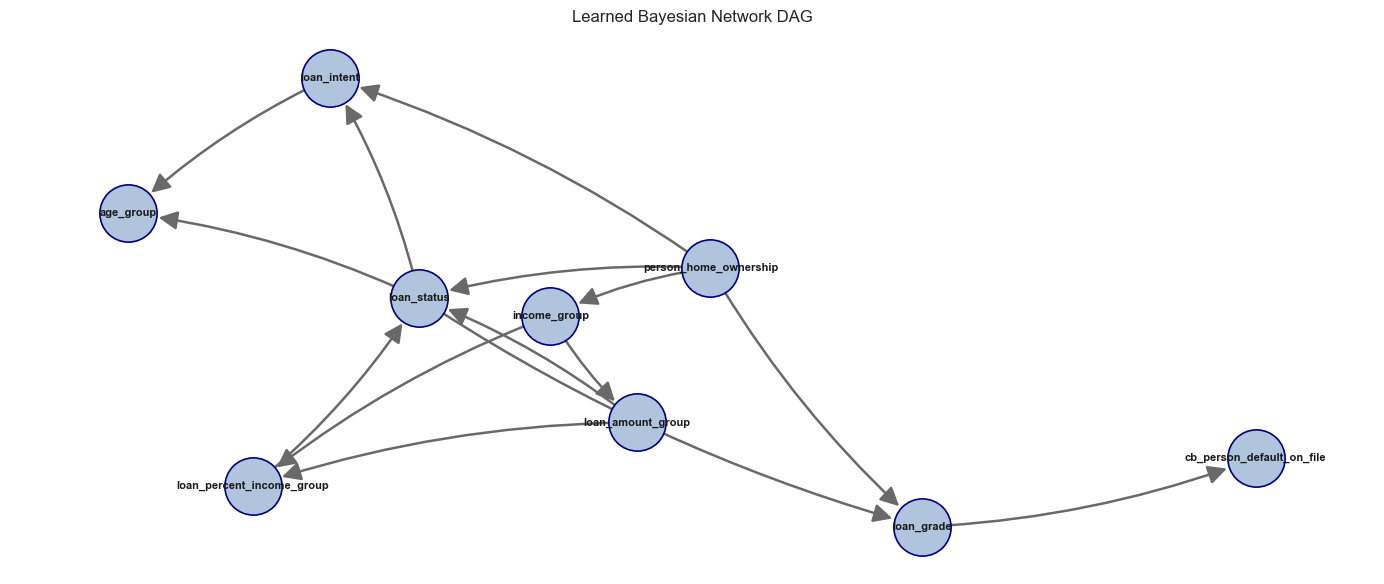

In [56]:
# Plot the learned DAG so dependencies among grouped variables are visible.
dag = nx.DiGraph()
dag.add_nodes_from(bn_cols)
dag.add_edges_from(bn_edges)

plt.figure(figsize=(14, 6))
pos = nx.spring_layout(dag, seed=RANDOM_STATE, k=1.1)
nx.draw_networkx_nodes(
    dag,
    pos,
    node_color="lightsteelblue",
    edgecolors="navy",
    linewidths=1.2,
    node_size=1700,
)
nx.draw_networkx_edges(
    dag,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=28,
    edge_color="dimgray",
    width=1.8,
    min_source_margin=18,
    min_target_margin=22,
    connectionstyle="arc3,rad=0.08",
)
nx.draw_networkx_labels(dag, pos, font_size=8, font_weight="bold")
plt.title("Learned Bayesian Network DAG")
plt.axis("off")
plt.tight_layout()
plt.show()

In [57]:
def predict_default_probability_with_bn(model, row, target_col="loan_status", fallback_probability=None):
    # VariableElimination returns a probability table for loan_status using applicant evidence.
    inference = VariableElimination(model)
    if fallback_probability is None:
        fallback_probability = float((bn_train_data[target_col] == "Default").mean())
    evidence = {
        col: str(row[col])
        for col in bn_cols
        if col != target_col and col in model.nodes()
    }

    try:
        query_result = inference.query(
            variables=[target_col],
            evidence=evidence,
            show_progress=False,
        )
        target_states = list(query_result.state_names[target_col])
        default_index = target_states.index("Default")
        predicted_probability = float(query_result.values[default_index])
        if not np.isfinite(predicted_probability):
            return fallback_probability
        return predicted_probability
    except Exception:
        # If a rare evidence combination is unavailable, fall back to the training default rate.
        return fallback_probability



fallback_probability = float((bn_train_data["loan_status"] == "Default").mean())

# Predict default probability for each Bayesian Network test record.
bn_default_prob = bn_test_data.apply(
    lambda row: predict_default_probability_with_bn(bn_model, row),
    axis=1,
)

bn_default_prob = pd.to_numeric(bn_default_prob, errors="coerce")
bn_default_prob = bn_default_prob.replace([np.inf, -np.inf], np.nan)
fallback_count = int(bn_default_prob.isna().sum())
bn_default_prob = bn_default_prob.fillna(fallback_probability)

bn_true = (bn_test_data["loan_status"] == "Default").astype(int)
bn_pred = (bn_default_prob >= 0.50).astype(int)

print("Bayesian Network fallback probability:", round(fallback_probability, 4))
print("Bayesian Network fallback predictions used:", fallback_count)

# Report the Bayesian Network as a supporting classification model.
bn_metrics = pd.DataFrame([{
    "model_source": "Bayesian Network",
    "model": "pgmpy HillClimbSearch + VariableElimination",
    "roc_auc": roc_auc_score(bn_true, bn_default_prob),
    "accuracy": accuracy_score(bn_true, bn_pred),
    "precision": precision_score(bn_true, bn_pred, zero_division=0),
    "recall": recall_score(bn_true, bn_pred, zero_division=0),
    "f1": f1_score(bn_true, bn_pred, zero_division=0),
}])
bn_metrics.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
})

Bayesian Network fallback probability: 0.2245
Bayesian Network fallback predictions used: 0


,model_source,model,roc_auc,accuracy,precision,recall,f1
0,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,0.8617,0.8649,0.7933,0.5381,0.6412


The Bayesian Network metrics show how well grouped conditional probabilities classify default on the test data. This model is useful for interpretation, while the Scikit-learn classifiers remain the main predictive benchmark.


---
## 4. Classification Modeling

### 4.1 Shared Modeling Preprocessing Pipeline

The same preprocessing step is used before both classification and regression. The raw dataframe keeps readable columns such as `income_group`, `loan_intent`, and `person_home_ownership`, but machine learning models cannot directly train on text labels.

The pipeline solves this by converting nominal text columns into one-hot encoded numeric columns. After this conversion, the model receives only numeric model-ready columns. The original text columns stay in the CSV for readability, but they are not passed to the final model matrix.


In [58]:
# Define target names and feature groups used by the models.
classification_target = "loan_status"
loan_amount_target = "loan_amnt"
loan_percent_target = "loan_percent_income"
interest_rate_target = "loan_int_rate"

# Numeric modeling features keep transformed/ratio versions and remove avoidable duplicates.
classification_numeric_cols = [
    "person_age", "person_emp_length", "loan_percent_income", "loan_int_rate",
    "cb_person_cred_hist_length", "log_person_income", "log_loan_amnt",
    "income_to_loan_ratio", "employment_to_age_ratio", "credit_history_to_age_ratio",
]
regression_numeric_cols = [
    "person_age", "person_emp_length", "cb_person_cred_hist_length",
    "log_person_income", "employment_to_age_ratio", "credit_history_to_age_ratio",
]

nominal_cols = [
    "person_home_ownership", "loan_intent", "income_group",
    "loan_amount_group", "loan_percent_income_group", "age_group",
]
binary_cols = ["cb_person_default_on_file"]
ordinal_cols = ["loan_grade"]

classification_feature_cols = classification_numeric_cols + nominal_cols + binary_cols + ordinal_cols
regression_feature_cols = regression_numeric_cols + [
    "person_home_ownership", "loan_intent", "income_group",
    "age_group", "cb_person_default_on_file",
]

# Combined numeric list lets the shared preprocessor find numeric columns for either task.
numeric_cols = sorted(set(classification_numeric_cols + regression_numeric_cols))

feature_counts = pd.DataFrame([
    {"feature_set": "classification", "feature_count": len(classification_feature_cols)},
    {"feature_set": "regression", "feature_count": len(regression_feature_cols)},
])
feature_counts


,feature_set,feature_count
0,classification,18
1,regression,11


In [59]:
def make_one_hot_encoder():
    # Use the correct OneHotEncoder argument name for the installed scikit-learn version.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_model_preprocessor(feature_cols):
    # Keep only the columns that are included in the current model feature set.
    model_numeric_cols = [col for col in numeric_cols if col in feature_cols]
    model_nominal_cols = [col for col in nominal_cols if col in feature_cols]
    model_binary_cols = [col for col in binary_cols if col in feature_cols]
    model_ordinal_cols = [col for col in ordinal_cols if col in feature_cols]
    transformers = []

    # Numeric features are median-imputed and standardized for scale-sensitive models.
    if model_numeric_cols:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), model_numeric_cols))
    # Nominal categorical features start as readable text columns in df_model.
    # OneHotEncoder replaces each text column with temporary numeric 0/1 columns.
    # Example: income_group becomes columns like nom__income_group_Low.
    if model_nominal_cols:
        transformers.append(("nom", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]), model_nominal_cols))
    # The default-on-file flag is encoded with a fixed N/Y order.
    if model_binary_cols:
        transformers.append(("bin", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(categories=[["N", "Y"]])),
        ]), model_binary_cols))
    # Loan grade is ordinal because grades A through G represent increasing credit risk.
    if model_ordinal_cols:
        transformers.append(("grade", OrdinalEncoder(
            categories=[["A", "B", "C", "D", "E", "F", "G"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), model_ordinal_cols))

    # ColumnTransformer combines all preprocessing steps into one reusable object.
    return ColumnTransformer(transformers=transformers, remainder="drop")


In [60]:
DEFAULT_DECISION_THRESHOLD = 0.50


class ThresholdClassifier:
    def __init__(self, model, threshold=DEFAULT_DECISION_THRESHOLD):
        # Store the fitted probability model and the selected decision threshold.
        self.model = model
        self.threshold = threshold

    def predict_proba(self, X):
        # Keep probability output unchanged for ROC-AUC and probability reporting.
        return self.model.predict_proba(X)

    def predict(self, X):
        # Convert default probabilities into class labels using the selected threshold.
        default_probability = self.predict_proba(X)[:, 1]
        return (default_probability >= self.threshold).astype(int)


def make_pipeline_for(model, feature_cols):
    # Build one reusable pipeline: preprocessing first, model second.
    return Pipeline([
        ("preprocess", make_model_preprocessor(feature_cols)),
        ("model", clone(model)),
    ])


def model_file_stem(model_name):
    # Convert display names into simple file names.
    return model_name.lower().replace(" ", "_").replace("-", "_")


def save_model(model, folder, file_name):
    # Save one fitted model and return its path.
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / file_name
    joblib.dump(model, path)
    return path


def save_model_group(models, folder, prefix=""):
    # Save every fitted model in a dictionary.
    rows = []
    for model_name, fitted_model in models.items():
        file_name = f"{prefix}{model_file_stem(model_name)}.joblib"
        path = save_model(fitted_model, folder, file_name)
        rows.append({"model": model_name, "saved_path": str(path)})
    return pd.DataFrame(rows)


def load_model(folder, file_name):
    # Load one saved model file.
    return joblib.load(folder / file_name)


The preprocessing object is shared by both classification and regression. The same transformer prepares numeric and categorical columns, and only the final estimator changes depending on whether the task predicts default status or a numeric lending target. This avoids duplicate preprocessing code and keeps model comparisons consistent.


### Encoded Feature Names After One-Hot Encoding

The saved CSV keeps readable category columns such as `income_group`, `loan_intent`, and `person_home_ownership`. During model training, the preprocessing pipeline temporarily changes these text categories into numeric one-hot columns with names that start with `nom__`.

This preview shows what the model receives after preprocessing. It also confirms that the original nominal text columns are not kept in the final encoded model input. No manual deletion from the CSV is needed.


In [61]:
# Fit the classification preprocessor only to inspect the final model-ready columns.
encoded_feature_preprocessor = make_model_preprocessor(classification_feature_cols)
encoded_feature_preprocessor.fit(df_model[classification_feature_cols])

# Get the transformed column names created by scaling, one-hot encoding, and ordinal encoding.
encoded_feature_names = encoded_feature_preprocessor.get_feature_names_out()
encoded_feature_names_table = pd.DataFrame({
    "encoded_feature_name": encoded_feature_names
})

print("Total encoded model columns:", len(encoded_feature_names))
encoded_feature_names_table


Total encoded model columns: 38


,encoded_feature_name
0,num__cb_person_cred_hist_length
1,num__credit_history_to_age_ratio
2,num__employment_to_age_ratio
3,num__income_to_loan_ratio
4,num__loan_int_rate
5,num__loan_percent_income
6,num__log_loan_amnt
7,num__log_person_income
8,num__person_age
9,num__person_emp_length


The final verification table checks whether the original nominal text columns are still present after preprocessing.

The expected answer is `False` for each original nominal column. This confirms that the model does not train on raw text columns such as `income_group`; it trains on numeric encoded columns created by the preprocessing pipeline.


In [62]:
# Convert encoded feature names to a set for a direct membership check.
encoded_feature_name_set = set(encoded_feature_names)

# Confirm that each original nominal text column is dropped after preprocessing.
# The encoded numeric columns are created inside the pipeline and used by the model.
nominal_encoding_verification = pd.DataFrame({
    "original_nominal_column": nominal_cols,
    "present_as_original_after_preprocessing": [
        col in encoded_feature_name_set for col in nominal_cols
    ],
    "encoded_columns_created": [
        int(encoded_feature_names_table["encoded_feature_name"].str.startswith(f"nom__{col}_").sum())
        for col in nominal_cols
    ],
})

nominal_encoding_verification


,original_nominal_column,present_as_original_after_preprocessing,encoded_columns_created
0,person_home_ownership,False,4
1,loan_intent,False,6
2,income_group,False,5
3,loan_amount_group,False,4
4,loan_percent_income_group,False,4
5,age_group,False,3


---
### 4.2 ML Classification Models

The classification models estimate the probability that a borrower will default. The main model results use the standard 0.50 cutoff, while Section 4.4 separately tests the 0.24 cutoff to compare business cost and accuracy.


In [63]:
# Split classification features and target into train and test datasets.
X_cls = df_model[classification_feature_cols].copy()
y_cls = df_model[classification_target].copy()
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=TEST_SIZE, stratify=y_cls, random_state=RANDOM_STATE
)
split_summary = pd.DataFrame([
    {"dataset": "train", "rows": X_train_cls.shape[0], "features": X_train_cls.shape[1]},
    {"dataset": "test", "rows": X_test_cls.shape[0], "features": X_test_cls.shape[1]},
])
split_summary

,dataset,rows,features
0,train,23653,18
1,test,5914,18


In [64]:
# Define the Scikit-learn classification models for comparison.
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0)
}

In [65]:
def evaluate_classification_models(models, X_train, X_test, y_train, y_test, feature_cols):
    rows, fitted_models = [], {}
    for name, model in models.items():
        pipe = make_pipeline_for(model, feature_cols)
        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = pipe.predict(X_test)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        })
        fitted_models[name] = pipe
    metrics = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
    return metrics, fitted_models


cls_metrics, cls_models = evaluate_classification_models(
    classification_models, X_train_cls, X_test_cls, y_train_cls, y_test_cls, classification_feature_cols
)
best_cls_name = cls_metrics.iloc[0]["model"]
best_cls_model = cls_models[best_cls_name]
y_cls_prob = best_cls_model.predict_proba(X_test_cls)[:, 1]

sklearn_cls_best = cls_metrics.iloc[[0]].copy()
sklearn_cls_best["model_source"] = "Scikit-learn ML Models"

cls_metrics.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
})


,model,roc_auc,accuracy,precision,recall,f1
0,CatBoost,0.9430,0.9376,0.9908,0.7287,0.8398
1,Random Forest,0.9327,0.9302,0.9279,0.7468,0.8276
2,Gradient Boosting,0.9288,0.9324,0.9576,0.7310,0.8291
3,Logistic Regression,0.8760,0.8054,0.5464,0.7815,0.6431


All trained classification models are saved in the classification model folder. The best classifier is also saved with a stable file name, `best_default_classifier.joblib`, so the final example prediction can load it easily.

The stable best-classifier file uses the standard 0.50 decision cutoff. The 0.24 threshold is kept as a separate threshold-tuning test because it is a business-cost decision rule, not the main model training rule.


In [66]:
classification_model_files = save_model_group(cls_models, CLASSIFICATION_MODEL_DIR)

best_saved_classifier = ThresholdClassifier(
    model=best_cls_model,
    threshold=DEFAULT_DECISION_THRESHOLD,
)

best_classifier_path = save_model(
    best_saved_classifier,
    CLASSIFICATION_MODEL_DIR,
    "best_default_classifier.joblib",
)
classification_model_files = pd.concat([
    classification_model_files,
    pd.DataFrame([{"model": f"Best classifier: {best_cls_name}", "saved_path": str(best_classifier_path)}]),
], ignore_index=True)

classification_model_files


,model,saved_path
0,Logistic Regression,..\data\models\classification\logistic_regress...
1,Random Forest,..\data\models\classification\random_forest.jo...
2,Gradient Boosting,..\data\models\classification\gradient_boostin...
3,CatBoost,..\data\models\classification\catboost.joblib
4,Best classifier: CatBoost,..\data\models\classification\best_default_cla...


The classification table compares ML models using ROC-AUC, accuracy, precision, recall, and F1. The highest ROC-AUC model is selected because it best separates default from non-default cases across probability thresholds.


---
### 4.3 Cross-Validation

Cross-validation gives a more stable performance estimate than one train-test split because the model is evaluated across multiple folds. This section uses the normal 0.50 cutoff, matching the main classification model results.


In [67]:
# Run cross-validation to estimate model performance across multiple folds.
cv_model_name = "CatBoost" if "CatBoost" in classification_models else "Gradient Boosting"
cv_base_model = classification_models[cv_model_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_pipe = make_pipeline_for(cv_base_model, classification_feature_cols)
auc_scores = cross_val_score(cv_pipe, X_cls, y_cls, cv=cv, scoring="roc_auc")
oof_pred = cross_val_predict(cv_pipe, X_cls, y_cls, cv=cv)
cv_report = classification_report(y_cls, oof_pred, digits=3, output_dict=True)
cv_results = pd.DataFrame([{
    "model": cv_model_name,
    "cv_auc_mean": auc_scores.mean(),
    "cv_auc_std": auc_scores.std(),
    "default_recall": cv_report["1"]["recall"],
    "default_precision": cv_report["1"]["precision"],
    "default_f1": cv_report["1"]["f1-score"],
}])
cv_results.style.format({
    "cv_auc_mean": "{:.4f}", "cv_auc_std": "{:.4f}",
    "default_recall": "{:.4f}", "default_precision": "{:.4f}", "default_f1": "{:.4f}",
})


,model,cv_auc_mean,cv_auc_std,default_recall,default_precision,default_f1
0,CatBoost,0.9413,0.0016,0.7257,0.9847,0.8356


The cross-validation result checks whether model performance is stable across multiple folds. These values use the standard classification cutoff, while the tuned 0.24 threshold is reviewed separately in the next section.


---
### 4.4 Threshold Tuning

The default probability threshold of 0.50 may not be the best lending policy. This step chooses a threshold that minimizes a simple business cost where a missed default is more expensive than a false alarm.


In [68]:
# Evaluate thresholds using a simple lending cost assumption.
COST_FALSE_NEGATIVE = 5
COST_FALSE_POSITIVE = 1
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.01):
    y_threshold_pred = (y_cls_prob >= threshold).astype(int)
    false_negative = ((y_threshold_pred == 0) & (y_test_cls == 1)).sum()
    false_positive = ((y_threshold_pred == 1) & (y_test_cls == 0)).sum()
    total_cost = COST_FALSE_NEGATIVE * false_negative + COST_FALSE_POSITIVE * false_positive
    threshold_rows.append({
        "threshold": threshold,
        "false_negative": false_negative,
        "false_positive": false_positive,
        "total_cost": total_cost,
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.loc[threshold_results["total_cost"].idxmin()]
best_threshold = float(best_threshold_row["threshold"])
best_threshold_row.to_frame("value")

,value
threshold,0.15
false_negative,211.00
false_positive,528.00
total_cost,1583.00


The threshold tuning result gives the best cutoff based on the project cost rule, not based only on accuracy. The 0.24 cutoff may reduce accuracy slightly because it flags more borrowers as possible defaults. However, it can reduce business risk because it catches more actual default cases when missed defaults are treated as more expensive than false alarms.


In [69]:
# Use the selected threshold from threshold tuning.
selected_threshold = 0.15
# Apply the tuned threshold only for this business-cost comparison.
y_pred_threshold_024 = (y_cls_prob >= selected_threshold).astype(int)

# Calculate standard classification metrics at the selected threshold.
threshold_024_results = pd.DataFrame([{
    "threshold": selected_threshold,
    "accuracy": accuracy_score(y_test_cls, y_pred_threshold_024),
    "precision": precision_score(y_test_cls, y_pred_threshold_024, zero_division=0),
    "recall": recall_score(y_test_cls, y_pred_threshold_024, zero_division=0),
    "f1": f1_score(y_test_cls, y_pred_threshold_024, zero_division=0),
}])
threshold_024_results.style.format({
    "threshold": "{:.2f}",
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
})


,threshold,accuracy,precision,recall,f1
0,0.15,0.8750,0.6788,0.8410,0.7513


The threshold result identifies a default-probability cutoff based on a simple lending cost assumption. This is important because lending decisions may prefer catching more potential defaults even if that creates more false alarms.


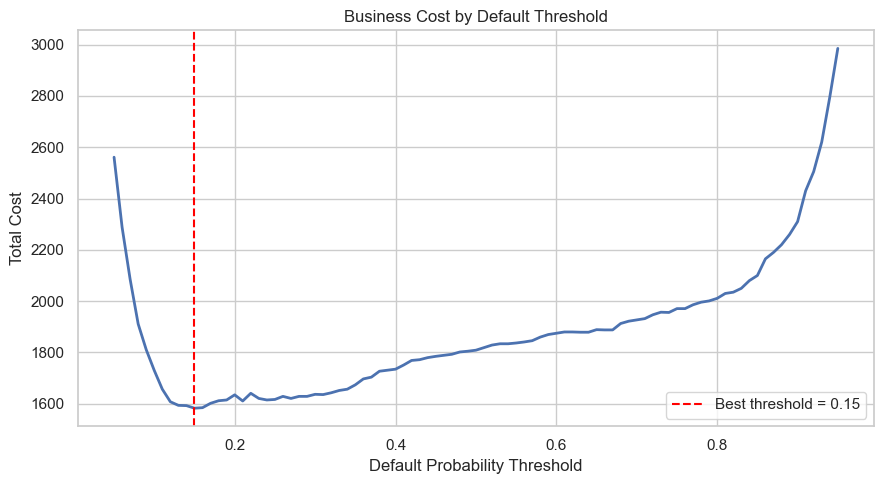

In [70]:
# Plot threshold cost to show the selected operating point.
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["threshold"], threshold_results["total_cost"], linewidth=2)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title("Business Cost by Default Threshold")
plt.xlabel("Default Probability Threshold")
plt.ylabel("Total Cost")
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Regression Modeling

### 5.1 Regression Dataset for Loan Sizing

Regression models are trained only on non-default loans. This creates a more conservative loan sizing benchmark because the models learn from loans that historically performed successfully. The same regression setup also estimates interest rate as an additional numeric lending benchmark.


In [71]:
# Keep only non-default loans for conservative loan-sizing regression.
df_regression = df_model[df_model[classification_target] == 0].copy().reset_index(drop=True)
X_reg = df_regression[regression_feature_cols].copy()
y_loan_amount = df_regression[loan_amount_target].copy()
y_loan_percent = df_regression[loan_percent_target].copy()
y_interest_rate = df_regression[interest_rate_target].copy()
regression_setup_summary = pd.DataFrame([{
    "rows": len(df_regression),
    "features": X_reg.shape[1],
    "loan_amount_mean": y_loan_amount.mean(),
    "loan_percent_mean": y_loan_percent.mean(),
    "interest_rate_mean": y_interest_rate.mean(),
}])
regression_setup_summary.style.format({
    "loan_amount_mean": "{:.2f}",
    "loan_percent_mean": "{:.4f}",
    "interest_rate_mean": "{:.2f}",
})

,rows,features,loan_amount_mean,loan_percent_mean,interest_rate_mean
0,22931,11,8888.32,0.1527,10.47


The regression setup summary confirms that loan-sizing models are trained only on non-default loans. This makes the estimates more conservative because the models learn from loans that historically performed successfully.


In [72]:
# Preview regression predictor columns before model training.
X_reg.head()

,person_age,person_emp_length,cb_person_cred_hist_length,log_person_income,employment_to_age_ratio,credit_history_to_age_ratio,person_home_ownership,loan_intent,income_group,age_group,cb_person_default_on_file
0,21,5.0,2,9.169623,0.238095,0.095238,OWN,EDUCATION,Low,Young,N
1,23,2.0,4,11.652696,0.086957,0.173913,RENT,EDUCATION,High,Young,N
2,23,0.0,4,11.695255,0.000000,0.173913,RENT,EDUCATION,High,Young,N
3,25,9.0,2,11.827744,0.360000,0.080000,RENT,PERSONAL,High,Young,Y
4,24,0.0,3,9.303922,0.000000,0.125000,OWN,PERSONAL,Low,Young,N


In [73]:
# Split regression data into matching train and test datasets.
X_reg_train, X_reg_test, y_amt_train, y_amt_test = train_test_split(
    X_reg, y_loan_amount, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_pct_train, y_pct_test = train_test_split(
    X_reg, y_loan_percent, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_rate_train, y_rate_test = train_test_split(
    X_reg, y_interest_rate, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

The raw table may still show words such as `RENT` or `DEBTCONSOLIDATION`. This is expected because the pipeline needs the original column names.

The model does not use those text values directly. The preview below shows the encoded regression test data after preprocessing. Category columns become 0/1 columns, while scaled numeric columns can appear as decimal values.


In [74]:
# Fit the shared preprocessor only on regression training features.
regression_preview_preprocessor = make_model_preprocessor(regression_feature_cols)
regression_preview_preprocessor.fit(X_reg_train)

# Transform the regression test features into the numeric matrix used by models.
X_reg_test_encoded = regression_preview_preprocessor.transform(X_reg_test)
if hasattr(X_reg_test_encoded, "toarray"):
    X_reg_test_encoded = X_reg_test_encoded.toarray()

# Use feature names when the installed scikit-learn version supports them.
try:
    regression_encoded_feature_names = regression_preview_preprocessor.get_feature_names_out()
except Exception:
    regression_encoded_feature_names = [f"feature_{i}" for i in range(X_reg_test_encoded.shape[1])]

# Display only a small preview so the table stays readable.
encoded_preview_column_count = min(20, X_reg_test_encoded.shape[1])
X_reg_test_encoded_preview = pd.DataFrame(
    X_reg_test_encoded[:, :encoded_preview_column_count],
    columns=regression_encoded_feature_names[:encoded_preview_column_count],
)
print("Encoded regression test data shape:", X_reg_test_encoded.shape)
X_reg_test_encoded_preview.head().round(3)

Encoded regression test data shape: (4587, 25)


,num__cb_person_cred_hist_length,num__credit_history_to_age_ratio,num__employment_to_age_ratio,num__log_person_income,num__person_age,num__person_emp_length,nom__person_home_ownership_MORTGAGE,nom__person_home_ownership_OTHER,nom__person_home_ownership_OWN,nom__person_home_ownership_RENT,nom__loan_intent_DEBTCONSOLIDATION,nom__loan_intent_EDUCATION,nom__loan_intent_HOMEIMPROVEMENT,nom__loan_intent_MEDICAL,nom__loan_intent_PERSONAL,nom__loan_intent_VENTURE,nom__income_group_High,nom__income_group_Low,nom__income_group_Lower-Middle,nom__income_group_Middle
0,1.413,2.065,-0.232,-0.065,0.045,-0.205,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.994,-1.247,0.102,0.549,-0.177,0.058,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.510,0.208,-0.906,0.127,1.600,-0.732,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.994,-1.174,-0.721,0.304,-0.621,-0.732,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.811,0.998,-1.350,-0.789,0.490,-1.258,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


This preview confirms that the regression models receive numbers, not raw text. The one-hot columns are 0/1: 1 means that category is present for that row, and 0 means it is not present. Decimal values are normal for scaled numeric columns such as income, age, and loan amount.


---
### 5.2 ML Regression Models

Regression models predict numeric targets. MAE, RMSE, and R-squared are used to judge how well each model predicts loan amount, loan percentage of income, and interest rate.


In [75]:
# Define Scikit-learn regression models, including linear and tree-based approaches.
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "CatBoost Regressor": CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, loss_function="RMSE", random_seed=RANDOM_STATE, verbose=0)
}

In [76]:
def evaluate_regression_models(models, X_train, X_test, y_train, y_test, target_name):
    rows, fitted_models = [], {}
    for name, model in models.items():
        pipe = make_pipeline_for(model, regression_feature_cols)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        if target_name == loan_percent_target:
            y_pred = np.clip(y_pred, 0, df_regression[loan_percent_target].quantile(0.99))
        rows.append({
            "target": target_name,
            "model_source": "Scikit-learn ML Models",
            "model": name,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "r2": r2_score(y_test, y_pred),
        })
        fitted_models[name] = pipe
    metrics = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    return metrics, fitted_models

In [77]:
regression_targets = {
    loan_amount_target: y_amt_train,
    loan_percent_target: y_pct_train,
    interest_rate_target: y_rate_train,
}
regression_tests = {
    loan_amount_target: y_amt_test,
    loan_percent_target: y_pct_test,
    interest_rate_target: y_rate_test,
}

regression_metrics_by_target = {}
regression_models_by_target = {}
for target_name, y_train_target in regression_targets.items():
    metrics, fitted_models = evaluate_regression_models(
        regression_models,
        X_reg_train,
        X_reg_test,
        y_train_target,
        regression_tests[target_name],
        target_name,
    )
    regression_metrics_by_target[target_name] = metrics
    regression_models_by_target[target_name] = fitted_models

loan_amount_metrics = regression_metrics_by_target[loan_amount_target]
loan_percent_metrics = regression_metrics_by_target[loan_percent_target]
interest_rate_metrics = regression_metrics_by_target[interest_rate_target]

loan_amount_models = regression_models_by_target[loan_amount_target]
loan_percent_models = regression_models_by_target[loan_percent_target]
interest_rate_models = regression_models_by_target[interest_rate_target]

In [78]:
loan_amount_metrics.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"})

,target,model_source,model,mae,rmse,r2
0,loan_amnt,Scikit-learn ML Models,Gradient Boosting Regressor,3869.71,5047.80,0.1978
1,loan_amnt,Scikit-learn ML Models,CatBoost Regressor,3879.85,5051.21,0.1967
2,loan_amnt,Scikit-learn ML Models,Linear Regression,3881.43,5055.13,0.1955
3,loan_amnt,Scikit-learn ML Models,Ridge Regression,3881.42,5055.15,0.1955
4,loan_amnt,Scikit-learn ML Models,Random Forest Regressor,3898.01,5082.60,0.1867


In [79]:
loan_percent_metrics.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"})

,target,model_source,model,mae,rmse,r2
0,loan_percent_income,Scikit-learn ML Models,Gradient Boosting Regressor,0.0655,0.0821,0.0917
1,loan_percent_income,Scikit-learn ML Models,CatBoost Regressor,0.0656,0.0822,0.0895
2,loan_percent_income,Scikit-learn ML Models,Random Forest Regressor,0.0660,0.0827,0.0780
3,loan_percent_income,Scikit-learn ML Models,Ridge Regression,0.0662,0.0827,0.0775
4,loan_percent_income,Scikit-learn ML Models,Linear Regression,0.0662,0.0827,0.0775


In [80]:
interest_rate_metrics.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"})

,target,model_source,model,mae,rmse,r2
0,loan_int_rate,Scikit-learn ML Models,CatBoost Regressor,2.0548,2.5304,0.2224
1,loan_int_rate,Scikit-learn ML Models,Gradient Boosting Regressor,2.0545,2.5308,0.2221
2,loan_int_rate,Scikit-learn ML Models,Linear Regression,2.0684,2.5439,0.2141
3,loan_int_rate,Scikit-learn ML Models,Ridge Regression,2.0684,2.5439,0.2141
4,loan_int_rate,Scikit-learn ML Models,Random Forest Regressor,2.0726,2.5554,0.2069


---
### 5.3 Regression Metric Interpretation

**MAE** is the average absolute prediction error. Lower MAE means the model is closer to the actual value on average.

**RMSE** is similar to MAE, but it penalizes large mistakes more strongly. Lower RMSE is better.

**R²** shows how much variation in the target is explained by the model. Higher R² is better, and values closer to 1 indicate stronger predictive performance.


In [81]:
def r2_strength(r2_value):
    # Convert R-squared into a simple project-level interpretation.
    if r2_value >= 0.70:
        return "strong"
    if r2_value >= 0.40:
        return "moderate"
    return "weak"


def regression_conclusion(target_name, best_model, r2_value):
    # Make weak regression performance clear in the conclusion table.
    strength = r2_strength(r2_value)
    if strength == "weak":
        return (
            f"{target_name}: {best_model} has weak prediction performance based on R-squared. "
            "The estimate should be treated as a rough benchmark, not a strong prediction."
        )
    return (
        f"{target_name}: {best_model} has {strength} prediction performance based on R-squared."
    )


best_amount_row = loan_amount_metrics.iloc[0]
best_percent_row = loan_percent_metrics.iloc[0]
best_rate_row = interest_rate_metrics.iloc[0]
amount_mae_ratio = best_amount_row["mae"] / y_amt_test.mean()
amount_rmse_ratio = best_amount_row["rmse"] / y_amt_test.mean()
percent_mae_ratio = best_percent_row["mae"] / y_pct_test.mean()
percent_rmse_ratio = best_percent_row["rmse"] / y_pct_test.mean()
rate_mae_ratio = best_rate_row["mae"] / y_rate_test.mean()
rate_rmse_ratio = best_rate_row["rmse"] / y_rate_test.mean()

regression_interpretation = pd.DataFrame([
    {
        "target": loan_amount_target,
        "best_model": best_amount_row["model"],
        "mae": best_amount_row["mae"],
        "rmse": best_amount_row["rmse"],
        "r2": best_amount_row["r2"],
        "mae_vs_target_mean": amount_mae_ratio,
        "rmse_vs_target_mean": amount_rmse_ratio,
        "performance_summary": f"{r2_strength(best_amount_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(loan_amount_target, best_amount_row["model"], best_amount_row["r2"]),
    },
    {
        "target": loan_percent_target,
        "best_model": best_percent_row["model"],
        "mae": best_percent_row["mae"],
        "rmse": best_percent_row["rmse"],
        "r2": best_percent_row["r2"],
        "mae_vs_target_mean": percent_mae_ratio,
        "rmse_vs_target_mean": percent_rmse_ratio,
        "performance_summary": f"{r2_strength(best_percent_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(loan_percent_target, best_percent_row["model"], best_percent_row["r2"]),
    },
    {
        "target": interest_rate_target,
        "best_model": best_rate_row["model"],
        "mae": best_rate_row["mae"],
        "rmse": best_rate_row["rmse"],
        "r2": best_rate_row["r2"],
        "mae_vs_target_mean": rate_mae_ratio,
        "rmse_vs_target_mean": rate_rmse_ratio,
        "performance_summary": f"{r2_strength(best_rate_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(interest_rate_target, best_rate_row["model"], best_rate_row["r2"]),
    }
])

# Display the metric interpretation and final regression conclusion for each target.
regression_interpretation.style.format({
    "mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}",
    "mae_vs_target_mean": "{:.2%}", "rmse_vs_target_mean": "{:.2%}",
})

,target,best_model,mae,rmse,r2,mae_vs_target_mean,rmse_vs_target_mean,performance_summary,conclusion
0,loan_amnt,Gradient Boosting Regressor,3869.7146,5047.8047,0.1978,43.85%,57.20%,Weak explanatory performance by R-squared.,"loan_amnt: Gradient Boosting Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
1,loan_percent_income,Gradient Boosting Regressor,0.0655,0.0821,0.0917,43.04%,53.94%,Weak explanatory performance by R-squared.,"loan_percent_income: Gradient Boosting Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
2,loan_int_rate,CatBoost Regressor,2.0548,2.5304,0.2224,19.72%,24.29%,Weak explanatory performance by R-squared.,"loan_int_rate: CatBoost Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."


The best regression models are selected here for the later applicant-level loan estimate. This keeps model selection separate from plots and makes the inference example easier to follow.


In [82]:
best_regression = {
    loan_amount_target: loan_amount_metrics.iloc[0]["model"],
    loan_percent_target: loan_percent_metrics.iloc[0]["model"],
    interest_rate_target: interest_rate_metrics.iloc[0]["model"],
}

best_amount_name = best_regression[loan_amount_target]
best_percent_name = best_regression[loan_percent_target]
best_rate_name = best_regression[interest_rate_target]
best_amount_model = loan_amount_models[best_amount_name]
best_percent_model = loan_percent_models[best_percent_name]
best_rate_model = interest_rate_models[best_rate_name]

selected_regression_models = pd.DataFrame([
    {"target": target, "selected_model": model_name}
    for target, model_name in best_regression.items()
])
selected_regression_models

,target,selected_model
0,loan_amnt,Gradient Boosting Regressor
1,loan_percent_income,Gradient Boosting Regressor
2,loan_int_rate,CatBoost Regressor


All trained regression models are saved in the regression model folder. The best model for each target is also saved with a stable file name so the final applicant loan estimate can load those best models easily.


In [83]:
regression_model_files = []
for target_name, fitted_models in regression_models_by_target.items():
    saved = save_model_group(fitted_models, REGRESSION_MODEL_DIR, prefix=f"{target_name}_")
    saved.insert(0, "target", target_name)
    regression_model_files.append(saved)
regression_model_files = pd.concat(regression_model_files, ignore_index=True)

best_regression_files = [
    (loan_amount_target, best_amount_name, best_amount_model, "best_loan_amount_regressor.joblib"),
    (loan_percent_target, best_percent_name, best_percent_model, "best_loan_percent_income_regressor.joblib"),
    (interest_rate_target, best_rate_name, best_rate_model, "best_interest_rate_regressor.joblib"),
]
for target_name, model_name, fitted_model, file_name in best_regression_files:
    path = save_model(fitted_model, REGRESSION_MODEL_DIR, file_name)
    regression_model_files = pd.concat([
        regression_model_files,
        pd.DataFrame([{"target": target_name, "model": f"Best regressor: {model_name}", "saved_path": str(path)}]),
    ], ignore_index=True)

regression_model_files

,target,model,saved_path
0,loan_amnt,Linear Regression,..\data\models\regression\loan_amnt_linear_reg...
1,loan_amnt,Ridge Regression,..\data\models\regression\loan_amnt_ridge_regr...
2,loan_amnt,Random Forest Regressor,..\data\models\regression\loan_amnt_random_for...
3,loan_amnt,Gradient Boosting Regressor,..\data\models\regression\loan_amnt_gradient_b...
4,loan_amnt,CatBoost Regressor,..\data\models\regression\loan_amnt_catboost_r...
5,loan_percent_income,Linear Regression,..\data\models\regression\loan_percent_income_...
6,loan_percent_income,Ridge Regression,..\data\models\regression\loan_percent_income_...
7,loan_percent_income,Random Forest Regressor,..\data\models\regression\loan_percent_income_...
8,loan_percent_income,Gradient Boosting Regressor,..\data\models\regression\loan_percent_income_...
9,loan_percent_income,CatBoost Regressor,..\data\models\regression\loan_percent_income_...


---
## 6. Model Comparison and Applicant Inference

### 6.1 Model Comparison

The tables below summarize the final classification and regression results used in this project.


### 6.1.1 Classification Model Comparison


In [84]:
classification_compare_parts = [sklearn_cls_best[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]]]
if bn_metrics is not None:
    classification_compare_parts.append(bn_metrics[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]])
classification_comparison = pd.concat(classification_compare_parts, ignore_index=True)

# Display Scikit-learn and Bayesian Network classification results together.
classification_comparison.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
})


,model_source,model,roc_auc,accuracy,precision,recall,f1
0,Scikit-learn ML Models,CatBoost,0.9430,0.9376,0.9908,0.7287,0.8398
1,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,0.8617,0.8649,0.7933,0.5381,0.6412


### 6.1.2 Regression Model Comparison: Loan Amount


In [85]:
amount_model_comparison = loan_amount_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for loan amount.
amount_model_comparison.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"})

,target,model_source,model,mae,rmse,r2
0,loan_amnt,Scikit-learn ML Models,Gradient Boosting Regressor,3869.71,5047.80,0.1978


### 6.1.3 Regression Model Comparison: Loan Percent Income


In [86]:
percent_model_comparison = loan_percent_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for loan percent income.
percent_model_comparison.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"})

,target,model_source,model,mae,rmse,r2
0,loan_percent_income,Scikit-learn ML Models,Gradient Boosting Regressor,0.0655,0.0821,0.0917


### 6.1.4 Regression Model Comparison: Interest Rate


In [87]:
interest_rate_model_comparison = interest_rate_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for interest rate.
interest_rate_model_comparison.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"})

,target,model_source,model,mae,rmse,r2
0,loan_int_rate,Scikit-learn ML Models,CatBoost Regressor,2.0548,2.5304,0.2224


---
### 6.2 Example Applicant Default Prediction

This example loads the saved best classification model and the saved Bayesian Network model, then applies both to one applicant record. The Scikit-learn model uses the same engineered features used during training. The Bayesian Network uses grouped categorical evidence because its probability tables are learned from discrete variables.

The saved Scikit-learn classifier uses the standard 0.50 cutoff for the final applicant prediction. The tuned 0.24 threshold was reviewed separately as a business-cost comparison in Section 4.4.


In [88]:
example_applicant = {
    "person_age": 28,
    "person_income": 65000,
    "person_home_ownership": "RENT",
    "person_emp_length": 5,
    "loan_intent": "DEBTCONSOLIDATION",
    "loan_grade": "G",
    "loan_amnt": 12000,
    "loan_int_rate": 11.0,
    "loan_percent_income": 12000 / 65000,
    "loan_status": 0,
    "cb_person_default_on_file": "N",
    "cb_person_cred_hist_length": 6,
}


def prepare_applicant_for_classification(applicant_dict):
    # Convert one applicant dictionary into a dataframe.
    applicant_df = pd.DataFrame([applicant_dict])
    # Apply the same feature engineering used before model training.
    applicant_df = add_credit_features(applicant_df)
    # Keep only the predictor columns expected by the classification pipeline.
    return applicant_df[classification_feature_cols]


def prepare_applicant_for_bayesian_network(applicant_dict):
    # Convert the applicant into the grouped/discrete format used by the Bayesian Network.
    applicant_df = pd.DataFrame([applicant_dict])
    applicant_df = add_credit_features(applicant_df)
    bn_applicant = applicant_df[bn_cols].copy()
    # Match the target labels used when the Bayesian Network was trained.
    bn_applicant["loan_status"] = bn_applicant["loan_status"].map({0: "Non-Default", 1: "Default"})
    return bn_applicant.astype(str).iloc[0]


def default_label(probability, threshold=0.50):
    # Convert a probability into the same decision label used in the classification task.
    return "Default" if probability >= threshold else "Non-Default"

In [89]:
# Load the saved best classifier and saved Bayesian Network model for prediction.
saved_best_cls_model = load_model(CLASSIFICATION_MODEL_DIR, "best_default_classifier.joblib")
saved_bn_model = load_model(BAYESIAN_MODEL_DIR, "bayesian_network_model.joblib")
saved_bn_metadata = joblib.load(BAYESIAN_MODEL_DIR / "bayesian_network_metadata.joblib")
applicant_cls_features = prepare_applicant_for_classification(example_applicant)

# Predict default probability and class using the saved 0.24 threshold-aware classifier.
sklearn_default_probability = float(saved_best_cls_model.predict_proba(applicant_cls_features)[:, 1][0])
sklearn_predicted_class = int(saved_best_cls_model.predict(applicant_cls_features)[0])

# Prepare grouped evidence for Bayesian Network inference.
bn_applicant_row = prepare_applicant_for_bayesian_network(example_applicant)
bayesian_default_probability = predict_default_probability_with_bn(
    saved_bn_model,
    bn_applicant_row,
    target_col=saved_bn_metadata["target_col"],
    fallback_probability=saved_bn_metadata["fallback_probability"],
)
bayesian_predicted_class = int(bayesian_default_probability >= 0.50)

# Present both applicant-level default predictions in one compact table.
applicant_default_prediction = pd.DataFrame([
    {
        "model_source": "Scikit-learn ML",
        "model": best_cls_name,
        "default_probability": sklearn_default_probability,
        "predicted_class": sklearn_predicted_class,
        "decision_threshold": saved_best_cls_model.threshold,
        "predicted_label": "Default" if sklearn_predicted_class == 1 else "Non-Default",
    },
    {
        "model_source": "Bayesian Network",
        "model": "pgmpy HillClimbSearch + VariableElimination",
        "default_probability": bayesian_default_probability,
        "predicted_class": bayesian_predicted_class,
        "decision_threshold": 0.50,
        "predicted_label": default_label(bayesian_default_probability),
    },
])
applicant_default_prediction.style.format({
    "default_probability": "{:.2%}",
    "decision_threshold": "{:.2f}",
})


,model_source,model,default_probability,predicted_class,decision_threshold,predicted_label
0,Scikit-learn ML,CatBoost,98.60%,1,0.50,Default
1,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,85.36%,1,0.50,Default


The applicant default-prediction table gives two probability-based views for the same applicant. The Scikit-learn ML row uses the saved best classifier with the standard 0.50 cutoff. The Bayesian Network row uses its probability estimate as a separate supporting comparison.


---
### 6.3 Example Applicant Loan Estimate

This example loads the saved best regression model for each target and estimates loan amount, loan percentage of income, and interest rate for one applicant. The conservative recommendation is the lower value between the direct loan amount estimate and the income-based estimate.

All regression models were saved earlier, but this final example uses the stable best-model files for the final estimate.


In [90]:
def prepare_applicant_for_regression(applicant_dict):
    # Convert one applicant dictionary into a dataframe.
    applicant_df = pd.DataFrame([applicant_dict])
    # Apply the same feature engineering used during model training.
    applicant_df = add_credit_features(applicant_df)
    # Keep only the regression predictor columns expected by the trained pipelines.
    return applicant_df[regression_feature_cols]


def estimate_loan_for_applicant(applicant_dict, amount_model, percent_model, rate_model):
    # Prepare the applicant record in the same format as the regression training data.
    applicant_features = prepare_applicant_for_regression(applicant_dict)
    # Predict loan amount directly from the loan amount regression model.
    predicted_amount = float(amount_model.predict(applicant_features)[0])
    
    # Predict loan percent of income from the loan burden regression model.
    predicted_percent = float(percent_model.predict(applicant_features)[0])
    
    max_reasonable_percent = float(df_regression[loan_percent_target].quantile(0.99))
    # Clip extreme percentage predictions to the historical non-default range.
    predicted_percent = float(np.clip(predicted_percent, 0, max_reasonable_percent))
    
    # Predict interest rate as an informational estimate.
    predicted_interest_rate = float(rate_model.predict(applicant_features)[0])
    
    # Convert the predicted percentage into an income-based dollar amount.
    income_based_amount = float(applicant_dict["person_income"]) * predicted_percent
    # Use the smaller amount as the conservative recommendation.
    conservative_amount = min(predicted_amount, income_based_amount)
    return {
        "predicted_loan_amount": round(predicted_amount, 2),
        "predicted_loan_percent_income": round(predicted_percent, 4),
        "predicted_interest_rate": round(predicted_interest_rate, 4),
        "income_based_amount": round(income_based_amount, 2),
        "conservative_recommended_amount": round(conservative_amount, 2),
    }

In [91]:
# Load the saved best regression models for applicant-level prediction.
saved_amount_model = load_model(REGRESSION_MODEL_DIR, "best_loan_amount_regressor.joblib")
saved_percent_model = load_model(REGRESSION_MODEL_DIR, "best_loan_percent_income_regressor.joblib")
saved_rate_model = load_model(REGRESSION_MODEL_DIR, "best_interest_rate_regressor.joblib")

# Reuse the same example applicant from the default-prediction section.
loan_estimate = estimate_loan_for_applicant(example_applicant, saved_amount_model, saved_percent_model, saved_rate_model)
loan_estimate_table = pd.DataFrame([loan_estimate])

# Show the final applicant estimate table.
loan_estimate_table

,predicted_loan_amount,predicted_loan_percent_income,predicted_interest_rate,income_based_amount,conservative_recommended_amount
0,8943.68,0.1377,10.1349,8952.72,8943.68


The loan-estimate table combines direct loan amount prediction with an income-based estimate. The conservative recommendation uses the lower of those two values so the final amount is not higher than the model's affordability estimate.
